In [ ]:
import pandas as pd
from google.colab import files
import io

# Upload a file. A file selection dialog will appear. Choose your CSV file.
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the uploaded file into a DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame
display(df.head())

Saving cancer_data.csv to cancer_data.csv
User uploaded file "cancer_data.csv" with length 34286266 bytes


,0,1,2,3,4,5,6,7,8,9,...,962,963,964,965,966,967,968,969,970,971
0,44.023542,9.216286,11.319078,33.215176,16.901427,9.031338,1.109961,20.017821,16.724363,10.494192,...,21.706486,16.315579,4.224009,8.602081,23.762341,8.302416,1.408731,4.295620,8.768768,1.0
1,29.746157,9.765600,40.540128,30.169134,20.047393,32.237287,2.460624,17.029112,28.346167,17.017284,...,12.815215,10.150965,8.914809,6.797915,15.379187,11.420690,6.599729,3.819019,5.758501,1.0
2,35.799315,9.884781,3.886043,29.984211,17.135946,21.273727,1.501203,20.598204,25.855152,12.275738,...,14.344729,11.224647,7.870991,7.724003,25.762396,8.628786,4.104879,4.382387,5.306177,1.0
3,26.490401,7.085828,10.804003,23.482255,17.044085,14.880104,1.299056,14.978582,31.214294,10.015235,...,13.660995,9.730124,7.804760,5.030966,8.964868,7.990036,4.251886,3.702483,7.500498,1.0
4,27.632466,7.642971,3.670265,16.584843,20.375321,22.174600,1.553541,14.909150,54.435490,13.392213,...,16.650019,8.584938,7.485410,5.945771,9.205302,8.761025,4.656969,3.827945,7.939863,1.0


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming the last column '971' is the label
# Separate features (X) and labels (y)
X = df.iloc[:, :-1] # All columns except the last one
y = df.iloc[:, -1]  # The last column

print("Shape of features (X):", X.shape)
print("Shape of labels (y):", y.shape)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling to the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

print("\nFirst 5 values of labels (y):")
display(y.head())

Shape of features (X): (2086, 971)
Shape of labels (y): (2086,)

First 5 rows of scaled features (X_scaled_df):


,0,1,2,3,4,5,6,7,8,9,...,961,962,963,964,965,966,967,968,969,970
0,0.237892,0.082832,0.020102,0.302737,0.050826,0.046596,0.013514,0.497457,0.038969,0.084320,...,0.069896,0.168754,0.341778,0.049079,0.186027,0.093705,0.112600,0.033977,0.092447,0.217877
1,0.145298,0.088527,0.077114,0.272476,0.061027,0.225673,0.034881,0.416975,0.069264,0.144424,...,0.165745,0.096844,0.195057,0.116374,0.143712,0.059204,0.162041,0.219174,0.081110,0.136299
2,0.184555,0.089762,0.005600,0.270638,0.051586,0.141069,0.019703,0.513086,0.062771,0.100735,...,0.109929,0.109214,0.220611,0.101399,0.165433,0.101937,0.117775,0.130167,0.094511,0.124041
3,0.124184,0.060745,0.019098,0.206044,0.051288,0.091730,0.016505,0.361757,0.076741,0.079907,...,0.127341,0.103684,0.185041,0.100449,0.102269,0.032805,0.107647,0.135411,0.078338,0.183507
4,0.131590,0.066521,0.005179,0.137520,0.062090,0.148021,0.020531,0.359887,0.137273,0.111023,...,0.139652,0.127859,0.157785,0.095868,0.123725,0.033795,0.119871,0.149863,0.081322,0.195414



First 5 values of labels (y):


,971
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 50 features using f_classif (ANOVA F-value for classification)
selector = SelectKBest(f_classif, k=50)
X_selected = selector.fit_transform(X_scaled_df, y)

# Get the names of the selected features
selected_feature_indices = selector.get_support(indices=True)
X_selected_df = pd.DataFrame(X_selected, columns=X_scaled_df.columns[selected_feature_indices])

print("Shape of features after selection (X_selected_df):", X_selected_df.shape)
print("\nFirst 5 rows of selected features (X_selected_df):")
display(X_selected_df.head())

Shape of features after selection (X_selected_df): (2086, 50)

First 5 rows of selected features (X_selected_df):


,6,41,54,62,81,122,164,169,189,241,...,790,805,820,849,861,875,889,936,953,966
0,0.013514,0.214720,0.046128,0.086048,0.016320,0.022597,0.060120,0.039011,0.031109,0.099085,...,0.189676,0.000057,0.009872,0.051745,0.194847,0.093627,0.071279,0.150912,0.015600,0.093705
1,0.034881,0.311170,0.026955,0.159423,0.042911,0.054110,0.091165,0.051351,0.029085,0.193280,...,0.095184,0.000029,0.072800,0.097260,0.453455,0.057104,0.095874,0.183912,0.201427,0.059204
2,0.019703,0.270290,0.088731,0.115119,0.020681,0.033112,0.059880,0.058293,0.046844,0.158633,...,0.209059,0.000060,0.020351,0.062981,0.182779,0.060807,0.080806,0.223805,0.191059,0.101937
3,0.016505,0.201366,0.042877,0.120326,0.035374,0.037049,0.039211,0.078285,0.026450,0.127099,...,0.242493,0.003981,0.019695,0.079227,0.192696,0.099107,0.088506,0.188866,0.330615,0.032805
4,0.020531,0.130451,0.023681,0.090729,0.055591,0.039928,0.069033,0.089363,0.073664,0.109755,...,0.169052,0.000072,0.024773,0.070988,0.206636,0.188158,0.079913,0.421153,0.312099,0.033795


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize the estimator (Logistic Regression is a good choice for RFE)
estimator = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)

# Initialize RFE with the estimator and the desired number of features
rfe_selector = RFE(estimator=estimator, n_features_to_select=50, step=1)

# Fit RFE to the scaled features and labels
X_rfe_selected = rfe_selector.fit_transform(X_scaled_df, y)

# Get the names of the selected features
rfe_selected_feature_indices = rfe_selector.get_support(indices=True)
X_rfe_selected_df = pd.DataFrame(X_rfe_selected, columns=X_scaled_df.columns[rfe_selected_feature_indices])

print("Shape of features after RFE selection (X_rfe_selected_df):", X_rfe_selected_df.shape)
print("\nFirst 5 rows of RFE selected features (X_rfe_selected_df):")
display(X_rfe_selected_df.head())

Shape of features after RFE selection (X_rfe_selected_df): (2086, 50)

First 5 rows of RFE selected features (X_rfe_selected_df):


,26,39,48,52,54,95,122,169,189,228,...,788,805,809,820,861,875,885,897,957,966
0,0.416119,0.355825,0.280523,0.304218,0.046128,0.199237,0.022597,0.039011,0.031109,0.221136,...,0.064502,0.000057,0.069479,0.009872,0.194847,0.093627,0.354453,0.398304,0.237256,0.093705
1,0.181850,0.358550,0.365411,0.416430,0.026955,0.195175,0.054110,0.051351,0.029085,0.239727,...,0.075759,0.000029,0.284177,0.072800,0.453455,0.057104,0.437275,0.112558,0.334791,0.059204
2,0.272263,0.271324,0.297237,0.264302,0.088731,0.148407,0.033112,0.058293,0.046844,0.305819,...,0.092609,0.000060,0.174682,0.020351,0.182779,0.060807,0.514944,0.133592,0.478483,0.101937
3,0.291732,0.268449,0.409690,0.837200,0.042877,0.175808,0.037049,0.078285,0.026450,0.220996,...,0.118641,0.003981,0.411631,0.019695,0.192696,0.099107,0.604811,0.148215,0.341877,0.032805
4,0.239554,0.476344,0.248728,0.207766,0.023681,0.292645,0.039928,0.089363,0.073664,0.278860,...,0.119420,0.000072,0.460214,0.024773,0.206636,0.188158,0.463091,0.145356,0.258264,0.033795


In [ ]:
# Install imbalanced-learn if you haven't already
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the RFE-selected features and labels
X_resampled, y_resampled = smote.fit_resample(X_rfe_selected_df, y)

print("Shape of features after SMOTE (X_resampled):", X_resampled.shape)
print("Shape of labels after SMOTE (y_resampled):", y_resampled.shape)

print("\nClass distribution after SMOTE:")
display(y_resampled.value_counts())

Shape of features after SMOTE (X_resampled): (4390, 50)
Shape of labels after SMOTE (y_resampled): (4390,)

Class distribution after SMOTE:


,count
971,
1.0,878
2.0,878
3.0,878
4.0,878
5.0,878


In [ ]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X_resampled,
                                                    y_resampled,
                                                    test_size=0.2,    # 20% for testing
                                                    random_state=42,  # For reproducibility
                                                    stratify=y_resampled) # Maintain class distribution

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in y_train:")
display(y_train.value_counts())
print("\nClass distribution in y_test:")
display(y_test.value_counts())

Shape of X_train: (3512, 50)
Shape of X_test: (878, 50)
Shape of y_train: (3512,)
Shape of y_test: (878,)

Class distribution in y_train:


,count
971,
2.0,703
5.0,703
3.0,702
4.0,702
1.0,702



Class distribution in y_test:


,count
971,
4.0,176
1.0,176
3.0,176
2.0,175
5.0,175


In [ ]:
import numpy as np

# Reshape X_train and X_test from 1D (50 features) to 2D image format (5x10, 1 channel)
# (num_samples, height, width, channels)
X_train_reshaped = X_train.values.reshape(X_train.shape[0], 5, 10, 1)
X_test_reshaped = X_test.values.reshape(X_test.shape[0], 5, 10, 1)

print("Shape of X_train after reshaping for CNN:", X_train_reshaped.shape)
print("Shape of X_test after reshaping for CNN:", X_test_reshaped.shape)

Shape of X_train after reshaping for CNN: (3512, 5, 10, 1)
Shape of X_test after reshaping for CNN: (878, 5, 10, 1)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(

    X_train_reshaped,
    y_train_0_indexed,

    validation_data=(
        X_test_reshaped,
        y_test_0_indexed
    ),

    epochs=50,
    batch_size=32,

    callbacks=[early_stop, reduce_lr],

    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9055 - loss: 0.2993 - val_accuracy: 0.3941 - val_loss: 1.5338 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9599 - loss: 0.1272 - val_accuracy: 0.7027 - val_loss: 1.3170 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9721 - loss: 0.0862 - val_accuracy: 0.7392 - val_loss: 0.8649 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9809 - loss: 0.0615 - val_accuracy: 0.9077 - val_loss: 0.2881 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9792 - loss: 0.0542 - val_accuracy: 0.9681 - val_loss: 0.1000 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9835 - loss: 0.0571 - val_accuracy: 0.9761 - val_loss: 0.0774 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9869 - loss: 0.

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_reshaped, y_test_0_indexed, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Test Loss: 0.0499
Test Accuracy: 0.9875


In [ ]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

In [ ]:
def build_cnn_model(hp):
    model = keras.Sequential()

    # First convolutional block
    model.add(keras.layers.Conv2D(
        filters=hp.Int('conv_1_filters', min_value=16, max_value=64, step=16),
        kernel_size=hp.Choice('conv_1_kernel_size', values=[3, 5]), # Choose integer, then convert to tuple
        activation='relu',
        input_shape=(5, 10, 1),
        padding='same'
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(keras.layers.Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Second convolutional block
    model.add(keras.layers.Conv2D(
        filters=hp.Int('conv_2_filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('conv_2_kernel_size', values=[3, 5]), # Choose integer, then convert to tuple
        activation='relu',
        padding='same'
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(keras.layers.Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(keras.layers.Flatten())

    model.add(keras.layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Dropout(hp.Float('dropout_3', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    num_classes = 5
    model.add(keras.layers.Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Initialize the Keras Tuner RandomSearch
tuner = kt.RandomSearch(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each trial to reduce noise
    directory='keras_tuner_dir', # Directory to store logs and checkpoints
    project_name='cnn_hyperparameter_tuning'
)

# Print a summary of the search space
tuner.search_space_summary()

Search space summary
Default search space size: 9
conv_1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
conv_1_kernel_size (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
conv_2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv_2_kernel_size (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
dropout_2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rat

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print(X_train_reshaped.shape, y_train_0_indexed.shape)
print(X_test_reshaped.shape, y_test_0_indexed.shape)

# Start the hyperparameter search
tuner.search(
    X_train_reshaped,
    y_train_0_indexed,
    epochs=30,
    validation_data=(X_test_reshaped, y_test_0_indexed),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)],
    verbose=1
)

Trial 10 Complete [00h 01m 27s]
val_accuracy: 0.990888386964798

Best val_accuracy So Far: 0.9920273423194885
Total elapsed time: 00h 17m 44s


In [ ]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print(f"  Conv_1 Filters: {best_hps.get('conv_1_filters')}")
print(f"  Conv_1 Kernel Size: {best_hps.get('conv_1_kernel_size')}")
print(f"  Dropout_1 Rate: {best_hps.get('dropout_1')}")
print(f"  Conv_2 Filters: {best_hps.get('conv_2_filters')}")
print(f"  Conv_2 Kernel Size: {best_hps.get('conv_2_kernel_size')}")
print(f"  Dropout_2 Rate: {best_hps.get('dropout_2')}")
print(f"  Dense Units: {best_hps.get('dense_units')}")
print(f"  Dropout_3 Rate: {best_hps.get('dropout_3')}")
print(f"  Learning Rate: {best_hps.get('learning_rate')}")

# Build the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Display the best model summary
best_model.summary()

Best hyperparameters found:
  Conv_1 Filters: 48
  Conv_1 Kernel Size: 5
  Dropout_1 Rate: 0.2
  Conv_2 Filters: 32
  Conv_2 Kernel Size: 5
  Dropout_2 Rate: 0.2
  Dense Units: 32
  Dropout_3 Rate: 0.1
  Learning Rate: 0.001997327676148322


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 5, 10, 48)      │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 10, 48)      │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 5, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 5, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 5, 32)       │        38,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,469 (181.52 KB)

 Trainable params: 46,245 (180.64 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
# Evaluate the best model on the test data
loss, accuracy = best_model.evaluate(X_test_reshaped, y_test_0_indexed, verbose=0)

print(f"\nBest Model Test Loss: {loss:.4f}")
print(f"Best Model Test Accuracy: {accuracy:.4f}")


Best Model Test Loss: 0.0203
Best Model Test Accuracy: 0.9954


### Confusion Matrix and Classification Report

To further evaluate the `best_model`'s performance, especially its ability to classify different classes, we will generate a confusion matrix and a classification report. This will provide insights into true positives, true negatives, false positives, and false negatives for each class, as well as precision, recall, and F1-score.

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


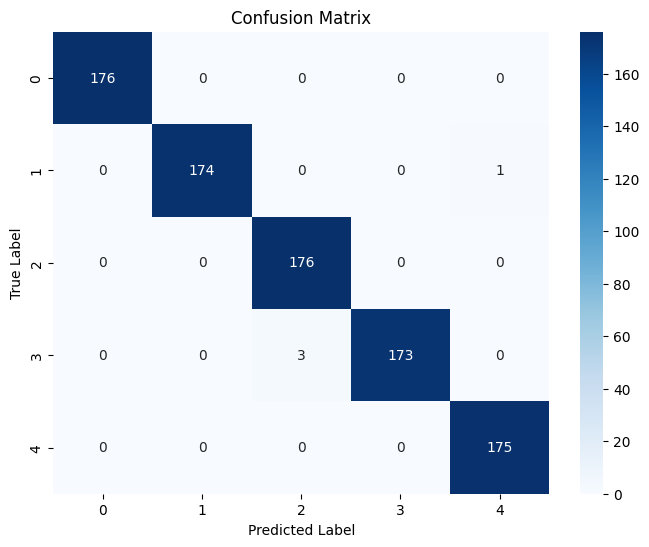


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      0.99      1.00       175
           2       0.98      1.00      0.99       176
           3       1.00      0.98      0.99       176
           4       0.99      1.00      1.00       175

    accuracy                           1.00       878
   macro avg       1.00      1.00      1.00       878
weighted avg       1.00      1.00      1.00       878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the best model on the test data
y_pred_probs = best_model.predict(X_test_reshaped)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Adjust y_test_0_indexed to be a 1D array of integers (if it isn't already)
y_true_labels = y_test_0_indexed.astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_true_labels), yticklabels=np.unique(y_true_labels))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate and print the classification report
print('\nClassification Report:')
print(classification_report(y_true_labels, y_pred_labels))

### ROC AUC Curve

To further assess the `best_model`'s performance across different classes, especially in terms of its ability to discriminate between positive and negative instances for each class, we will plot the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC) for each class. This is particularly useful for multi-class classification problems.

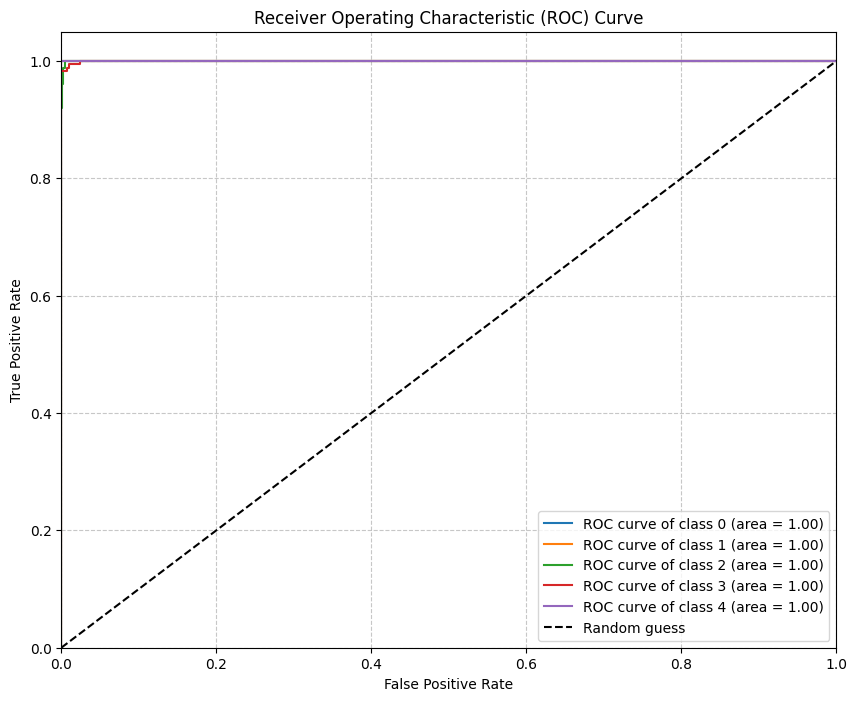

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the true labels for ROC AUC calculation
y_test_binarized = label_binarize(y_test_0_indexed, classes=np.arange(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## CNN Model Evaluation Without SMOTE

To understand the impact of SMOTE on model performance, we will now train and evaluate the best CNN model architecture found during hyperparameter tuning, but this time using the original, imbalanced dataset (i.e., without applying SMOTE augmentation). We will follow a similar evaluation process, including training, testing, confusion matrix, classification report, and ROC AUC curves.

### 1. Prepare Data Without SMOTE

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Use the RFE-selected features and original labels (before SMOTE)
X_no_smote = X_rfe_selected_df
y_no_smote = y

print("Shape of features without SMOTE (X_no_smote):", X_no_smote.shape)
print("Shape of labels without SMOTE (y_no_smote):", y_no_smote.shape)

# Split the non-SMOTE data into training and testing sets (80/20 ratio)
X_train_no_smote, X_test_no_smote, y_train_no_smote, y_test_no_smote = train_test_split(
    X_no_smote,
    y_no_smote,
    test_size=0.2,    # 20% for testing
    random_state=42,  # For reproducibility
    stratify=y_no_smote # Maintain original class distribution
)

# Convert labels to 0-indexed for sparse_categorical_crossentropy
y_train_0_indexed_no_smote = y_train_no_smote - 1
y_test_0_indexed_no_smote = y_test_no_smote - 1

print("\nShape of X_train_no_smote:", X_train_no_smote.shape)
print("Shape of X_test_no_smote:", X_test_no_smote.shape)
print("Shape of y_train_0_indexed_no_smote:", y_train_0_indexed_no_smote.shape)
print("Shape of y_test_0_indexed_no_smote:", y_test_0_indexed_no_smote.shape)

# Reshape X_train and X_test from 1D (50 features) to 2D image format (5x10, 1 channel)
# (num_samples, height, width, channels)
X_train_reshaped_no_smote = X_train_no_smote.values.reshape(X_train_no_smote.shape[0], 5, 10, 1)
X_test_reshaped_no_smote = X_test_no_smote.values.reshape(X_test_no_smote.shape[0], 5, 10, 1)

print("\nShape of X_train_no_smote after reshaping for CNN:", X_train_reshaped_no_smote.shape)
print("Shape of X_test_no_smote after reshaping for CNN:", X_test_reshaped_no_smote.shape)

Shape of features without SMOTE (X_no_smote): (2086, 50)
Shape of labels without SMOTE (y_no_smote): (2086,)

Shape of X_train_no_smote: (1668, 50)
Shape of X_test_no_smote: (418, 50)
Shape of y_train_0_indexed_no_smote: (1668,)
Shape of y_test_0_indexed_no_smote: (418,)

Shape of X_train_no_smote after reshaping for CNN: (1668, 5, 10, 1)
Shape of X_test_no_smote after reshaping for CNN: (418, 5, 10, 1)


### 2. Train the Best Model Architecture Without SMOTE

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Re-build a fresh model using the best hyperparameters found by the tuner
best_model_no_smote = tuner.hypermodel.build(best_hps)

# Define callbacks for training
early_stop_no_smote = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
reduce_lr_no_smote = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("Training CNN model without SMOTE...")
history_no_smote = best_model_no_smote.fit(
    X_train_reshaped_no_smote,
    y_train_0_indexed_no_smote,
    validation_data=(X_test_reshaped_no_smote, y_test_0_indexed_no_smote),
    epochs=50, # Use a sufficient number of epochs, EarlyStopping will handle it
    batch_size=32,
    callbacks=[early_stop_no_smote, reduce_lr_no_smote],
    verbose=1
)

# Evaluate the model on the test data
loss_no_smote, accuracy_no_smote = best_model_no_smote.evaluate(X_test_reshaped_no_smote, y_test_0_indexed_no_smote, verbose=0)

print(f"\nModel without SMOTE Test Loss: {loss_no_smote:.4f}")
print(f"Model without SMOTE Test Accuracy: {accuracy_no_smote:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN model without SMOTE...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8561 - loss: 0.4413 - val_accuracy: 0.0957 - val_loss: 1.5548 - learning_rate: 0.0020
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9580 - loss: 0.1548 - val_accuracy: 0.2416 - val_loss: 1.4583 - learning_rate: 0.0020
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9604 - loss: 0.1351 - val_accuracy: 0.5550 - val_loss: 1.2796 - learning_rate: 0.0020
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9586 - loss: 0.1172 - val_accuracy: 0.6842 - val_loss: 1.0432 - learning_rate: 0.0020
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9688 - loss: 0.1046 - val_accuracy: 0.8756 - val_loss: 0.8874 - learning_rate: 0.0020
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9646 - loss: 0.1223 - val_accuracy: 0.9522 - val_loss: 0.5240 - learning_rate: 0.0020
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accur

### 3. Confusion Matrix and Classification Report (Without SMOTE)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


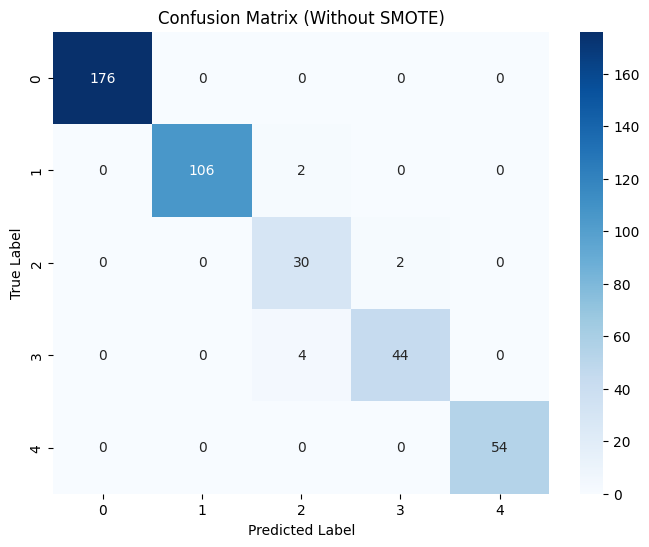


Classification Report (Without SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      0.98      0.99       108
           2       0.83      0.94      0.88        32
           3       0.96      0.92      0.94        48
           4       1.00      1.00      1.00        54

    accuracy                           0.98       418
   macro avg       0.96      0.97      0.96       418
weighted avg       0.98      0.98      0.98       418



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the model trained without SMOTE on the test data
y_pred_probs_no_smote = best_model_no_smote.predict(X_test_reshaped_no_smote)
y_pred_labels_no_smote = np.argmax(y_pred_probs_no_smote, axis=1)

# Ensure true labels are integer type
y_true_labels_no_smote = y_test_0_indexed_no_smote.astype(int)

# Generate the confusion matrix
cm_no_smote = confusion_matrix(y_true_labels_no_smote, y_pred_labels_no_smote)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_no_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_true_labels_no_smote), yticklabels=np.unique(y_true_labels_no_smote))
plt.title('Confusion Matrix (Without SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate and print the classification report
print('\nClassification Report (Without SMOTE):')
print(classification_report(y_true_labels_no_smote, y_pred_labels_no_smote))

### 4. ROC AUC Curve (Without SMOTE)

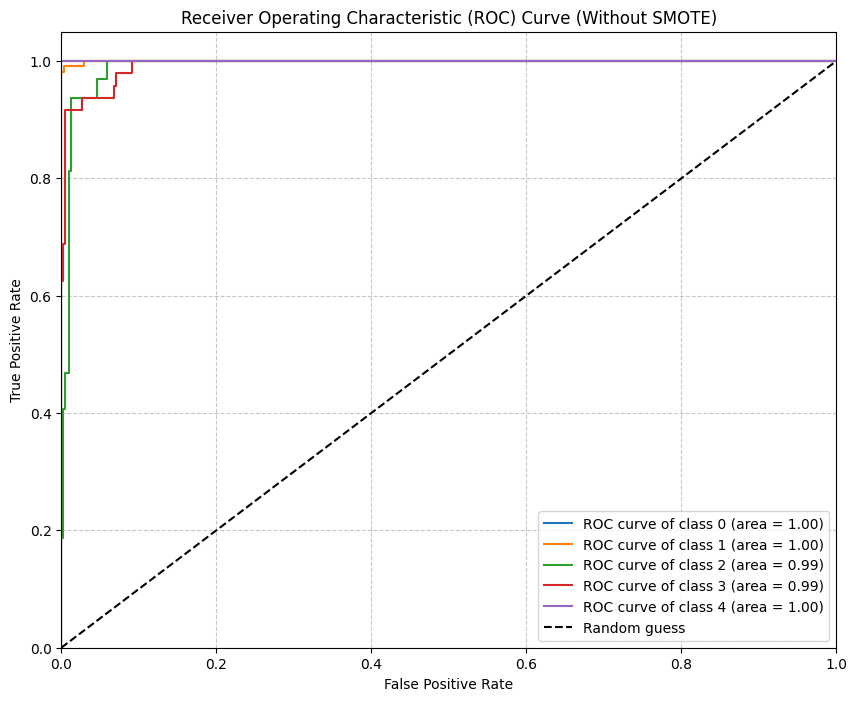

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the true labels for ROC AUC calculation
y_test_binarized_no_smote = label_binarize(y_test_0_indexed_no_smote, classes=np.arange(num_classes))

# Compute ROC curve and ROC area for each class
fpr_no_smote = dict()
tpr_no_smote = dict()
roc_auc_no_smote = dict()
for i in range(num_classes):
    fpr_no_smote[i], tpr_no_smote[i], _ = roc_curve(y_test_binarized_no_smote[:, i], y_pred_probs_no_smote[:, i])
    roc_auc_no_smote[i] = auc(fpr_no_smote[i], tpr_no_smote[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr_no_smote[i], tpr_no_smote[i], label=f'ROC curve of class {i} (area = {roc_auc_no_smote[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Without SMOTE)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The hyperparameter tuning process is complete, and the best model has been evaluated on the test set. You now have the final performance metrics for the optimized CNN model.

With the hyperparameter tuning complete, we have identified the optimal architecture and learning rate for the CNN model. The next step is to re-evaluate this best model on the test dataset to get its final performance metrics.

In [ ]:
def build_cnn_model(hp):
    model = keras.Sequential()

    model.add(keras.layers.Conv2D(
        filters=hp.Int('conv_1_filters', min_value=16, max_value=64, step=16),
        kernel_size=hp.Choice('conv_1_kernel', values=[(3,3), (5,5)]),
        activation='relu',
        input_shape=(5, 10, 1),
        padding='same'
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(keras.layers.Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Add a second convolutional block
    model.add(keras.layers.Conv2D(
        filters=hp.Int('conv_2_filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('conv_2_kernel', values=[(3,3), (5,5)]),
        activation='relu',
        padding='same'
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(keras.layers.Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(keras.layers.Flatten())

    model.add(keras.layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Dropout(hp.Float('dropout_3', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    # The variable `num_classes` is available in the kernel state, but defining it here
    # makes the function more self-contained. From context, there are 5 classes.
    num_classes = 5
    model.add(keras.layers.Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

With the hyperparameter tuning complete, we have identified the optimal architecture and learning rate for the CNN model. The next step is to re-evaluate this best model on the test dataset to get its final performance metrics.